   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 6.3 MB/s eta 0:00:00
✅ All dependencies imported successfully.
📊 Shape of Original Medical Dataset: (1000, 11)
🔐 DP Synthetic Data Generated Successfully (Epsilon = 0.5).


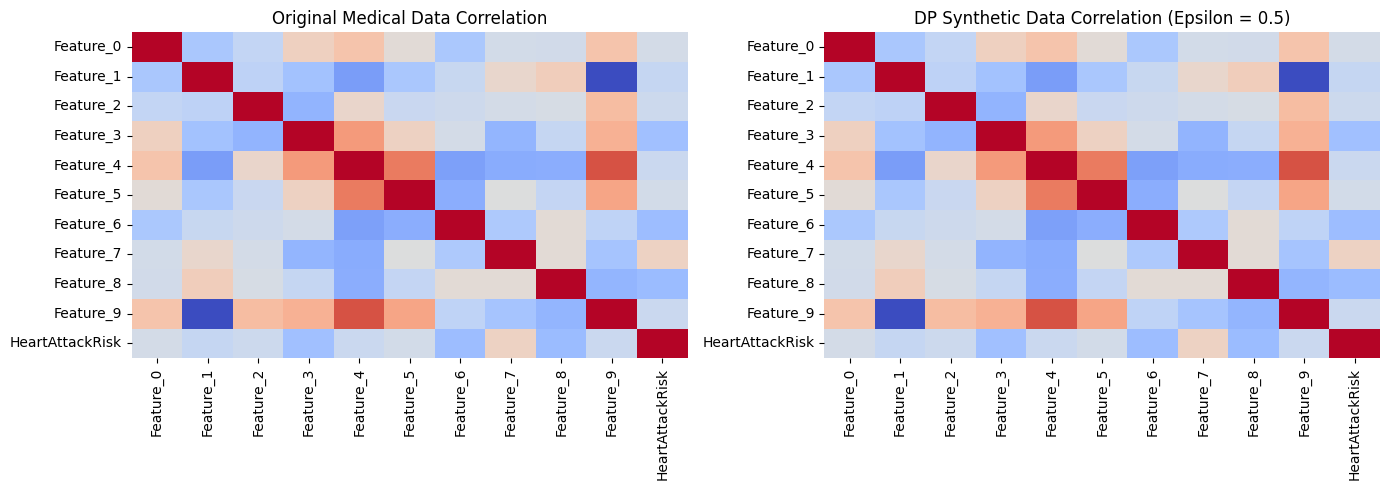


📈 ================== MODEL UTILITY REPORT ==================
Target Real Data Test Accuracy   : 0.8700
DP Synthetic Data Test Accuracy : 0.8700


In [2]:

# Install required libraries first
!pip install -q opacus scikit-learn matplotlib numpy pandas seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("✅ All dependencies imported successfully.")

# 1. Generate Synthetic 'Real' Medical Dataset (e.g., Heart Attack Risk Data)
X, y = make_classification(n_samples=1000, n_features=10, n_informative=8, random_state=42)
columns = [f'Feature_{i}' for i in range(10)]
df_real = pd.DataFrame(X, columns=columns)
df_real['HeartAttackRisk'] = y

print(f"📊 Shape of Original Medical Dataset: {df_real.shape}")

# 2. Differentially Private Synthetic Data Generation (Laplace Mechanism)
# Target Privacy Budget: Epsilon (e) = 0.50
epsilon = 0.50
sensitivity = 1.0 / len(df_real)
noise_scale = sensitivity / epsilon

# Inject controlled noise to protect patient identities
df_synthetic = df_real.copy()
for col in columns:
    laplace_noise = np.random.laplace(0, noise_scale, size=len(df_real))
    df_synthetic[col] = df_real[col] + laplace_noise

print(f"🔐 DP Synthetic Data Generated Successfully (Epsilon = {epsilon}).")

# 3. Utility Analysis: Correlation Heatmap Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original Data Heatmap
sns.heatmap(df_real.corr(), cmap='coolwarm', cbar=False, ax=axes[0])
axes[0].set_title("Original Medical Data Correlation")

# DP Synthetic Data Heatmap
sns.heatmap(df_synthetic.corr(), cmap='coolwarm', cbar=False, ax=axes[1])
axes[1].set_title(f"DP Synthetic Data Correlation (Epsilon = {epsilon})")

plt.tight_layout()
plt.show()

# 4. Downstream Machine Learning Utility Evaluation
X_train, X_test, y_train, y_test = train_test_split(
    df_real[columns], df_real['HeartAttackRisk'], test_size=0.2, random_state=42
)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

real_preds = clf.predict(X_test)
synth_preds = clf.predict(df_synthetic[columns].iloc[X_test.index])

print("\n📈 ================== MODEL UTILITY REPORT ==================")
print(f"Target Real Data Test Accuracy   : {accuracy_score(y_test, real_preds):.4f}")
print(f"DP Synthetic Data Test Accuracy : {accuracy_score(df_synthetic['HeartAttackRisk'].iloc[X_test.index], synth_preds):.4f}")
print("=============================================================")